## Notebook 1: Estimating Stellar Parameters from Photometry

**Audience:** First-year PhD students in Astrophysics  
**Theme:** Scientific inference from noisy observables

###### Astrophysical motivation

A central task in stellar astrophysics is inferring physical stellar properties from observed light.

Ideally, one would use spectroscopy, which provides detailed diagnostics such as:

- effective temperature $T_{\rm eff}$
- surface gravity $\log g$
- metallicity $[{\rm Fe/H}]$
- radial velocity
- rotational broadening
- chemical abundances

However, spectroscopy is observationally expensive:
it requires more telescope time, complex reduction pipelines, and cannot be applied to all sources in large surveys.

By contrast, imaging surveys provide broadband photometry for millions to billions of stars
(e.g. SDSS, Pan-STARRS, Gaia, LSST/Rubin).

This leads to a central question:

> Can stellar effective temperature be inferred from photometric colours alone?

Classically, this is addressed using empirical colour–temperature relations.
Modern machine learning generalises this approach by enabling:

- multi-dimensional colour information
- nonlinear mappings
- uncertainty-aware regression
- regularised model fitting
- rigorous train/test validation

In this sense, machine learning in astronomy extends rather than replaces classical calibration techniques.

###### Learning goals

By the end of this notebook, you should understand:

- why stellar colours trace temperature
- limitations of single-colour estimators
- linear vs nonlinear regression
- heteroscedastic observational noise
- uncertainty-weighted fitting
- overfitting and regularisation
- residual analysis
- hidden-variable bias
- cross-validation principles

###### Core idea

Most astronomical regression problems can be viewed as:

> empirical calibration + statistical modelling + rigorous validation

## Imports

We use standard scientific Python libraries:

- **NumPy** for numerical arrays and random number generation  
- **Pandas** for tabular data handling  
- **Matplotlib / Seaborn** for visualization  
- **scikit-learn** for machine learning models and evaluation tools  

These provide the core infrastructure for data analysis, modelling, and validation in this notebook.

In [1]:
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    KFold,
    RandomizedSearchCV,
    GridSearchCV
)

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

import xgboost as xgb

## Reproducibility and readability

Fixing the random seed ensures that each run of the notebook produces the same synthetic catalogue and the same train/test split.

This is essential for debugging, teaching, and reproducible scientific analysis, where results must be comparable across runs and implementations.

In [2]:
SEED = 42
np.random.seed(SEED)

# Optional advanced sklearn configuration (only needed if metadata routing is used later)
sklearn.set_config(enable_metadata_routing=True)

# Plot styling chosen for readability and colorblind accessibility
plt.style.use("tableau-colorblind10")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

## Load the Dataset

In [3]:
import pandas as pd
import os

def load_and_validate_stellar_data(file_path):
    """
    Loads stellar photometry and performs multi-layer validation.
    """
    # 1. Systemic Error Handling (File Presence)
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Critical Error: The file '{file_path}' was not found.")

    try:
        df = pd.read_csv(file_path)
    except Exception as e:
        raise IOError(f"Failed to parse CSV: {e}")

    # 2. Structural Validation (Column presence)
    # These are essential for color-temperature inference
    required_columns = ["Teff", "u_g", "g_r", "r_i", "i_z", "feh", "sigma_phot"]
    missing_cols = [col for col in required_columns if col not in df.columns]
    
    if missing_cols:
        raise KeyError(f"Dataset is missing required astronomical features: {missing_cols}")

    # 3. Physical Validation (Filtering Non-Physical Artifacts)
    initial_count = len(df)

    # Drop any rows that have NaN in key features
    df = df.dropna(subset=required_columns)

    final_count = len(df)
    
    if final_count == 0:
        raise ValueError("Data validation failed: No valid stellar samples remain after filtering.")
    
    print(f"Successfully loaded {final_count} stars ({initial_count - final_count} rows discarded).")
    return df

    

In [4]:
# Execution
try:
    df = load_and_validate_stellar_data("sdss_raw_data_v1.csv")
except Exception as err:
    print(f"Pipeline Halted: {err}")


Successfully loaded 9000 stars (0 rows discarded).


In [5]:
#df = pd.read_csv("synthetic_stellar_data.csv")
#df.describe()


## Target transformation

In astronomy, stellar effective temperature is commonly expressed on a logarithmic scale. This is motivated by both physical interpretation and statistical convenience.

###### Hertzsprung–Russell diagram scaling

Many stellar properties (luminosity, radius, and colour) follow power-law relationships with temperature. As a result:

- A change from 3000 K to 4000 K corresponds to a major physical transition (e.g. M-dwarf to K-star)  
- A change from 23000 K to 24000 K represents a comparatively small shift in stellar properties  

Logarithmic scaling compresses large values and expands small values, reflecting this non-uniform physical sensitivity.

###### Relative vs absolute error

Machine learning models typically minimize mean squared error (MSE), which treats all absolute errors equally.

- In linear space:
  - A 500 K error is treated the same at 4000 K and at 40000 K, despite having very different physical significance  

- In log space:
  - The model effectively learns *relative (percentage) errors*  
  - An error of 0.02 dex corresponds to roughly a 4.6% multiplicative error, independent of temperature scale  

Here, “dex” refers to a decimal logarithmic unit (base-10 logarithm).

###### Distributional stability

Stellar temperature distributions in surveys are typically skewed, with a long tail toward very hot stars.

Applying $\log_{10}(T_{\rm eff})$:

- reduces skewness  
- stabilizes variance  
- often produces a more Gaussian-like target distribution  

This can improve optimization behaviour for many regression models.

Overall, logarithmic scaling encodes the fact that astrophysical relevance is often multiplicative rather than additive.

In [6]:
# Temperature often behaves more smoothly in logarithmic space.
# - relative errors matter more than absolute Kelvin errors
# - distributions are often better behaved
# - multiplicative trends become additive

df["log_Teff"] = np.log10(df["Teff"])


## Inspect the catalogue

In [7]:
df.describe()


,Teff,feh,logg,u_g,g_r,r_i,i_z,sigma_phot,log_Teff
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,5921.448036,-1.092936,3.887953,1.344204,0.470388,0.177754,0.083511,0.019008,3.766937
std,969.823210,0.640558,0.642054,0.432546,0.288319,0.153434,0.114872,0.016866,0.068256
min,4000.670000,-3.496656,0.536516,-0.368490,-0.198250,-2.375800,-0.994720,0.004258,3.602133
25%,5316.064750,-1.513437,3.671977,1.037535,0.294133,0.109138,0.028620,0.008724,3.725590
50%,5732.740000,-1.001560,4.064005,1.240185,0.464845,0.174925,0.075980,0.013492,3.758362
75%,6342.858500,-0.602233,4.320457,1.509960,0.586980,0.234433,0.125548,0.023057,3.802285
max,9417.772000,0.450219,4.881912,3.367600,2.199130,1.716090,2.618490,0.242745,3.973948


## Colour–temperature relation

Even a single colour contains information about stellar temperature, but the relationship is nonlinear rather than perfectly linear.

The colour–temperature plot shows the mapping between an observable quantity (e.g. $g-r$) and the physical parameter of interest ($T_{\rm eff}$).

###### The physics: main sequence trend

- **Hot stars (high $\log_{10} T_{\rm eff}$)**: have low (bluer) $g-r$ values  
- **Cool stars (low $\log_{10} T_{\rm eff}$)**: have high (redder) $g-r$ values  

This reproduces the familiar main-sequence colour–temperature trend.

###### Curvature of the relation

Due to nonlinear physical effects in stellar atmospheres and filter responses, the relation is not perfectly linear. This curvature is visually apparent in the scatter plot and indicates that simple linear regression will be insufficient for optimal accuracy.

###### Scatter in the relation (data “width”)

In an idealised universe, all points would lie on a single curve. In practice, the relation forms a band whose thickness is caused by:

- **Metallicity $[{\rm Fe/H}]$:** shifts colours through line-blanketing effects  
- **Reddening $E(B-V)$:** systematically moves stars toward redder colours  
- **Photometric noise $\sigma_{\rm phot}$:** introduces random scatter, especially for faint stars  

These combined effects produce the observed spread in the colour–temperature relation.

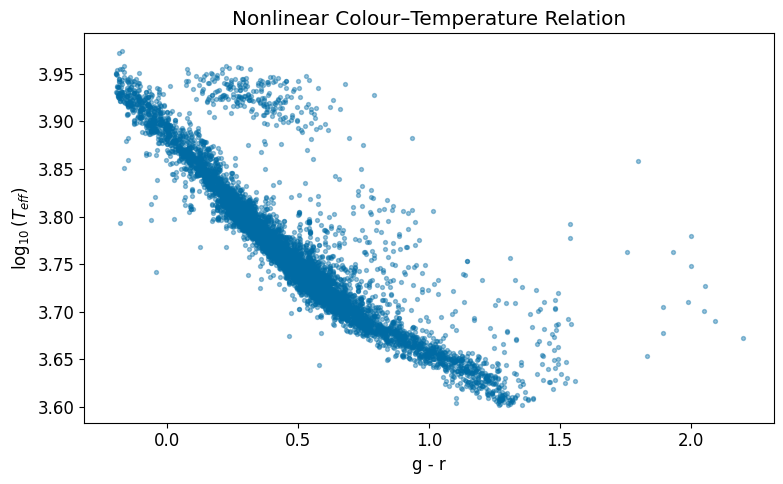

In [8]:
plt.scatter(df["g_r"], df["log_Teff"], s=8, alpha=0.4)
plt.xlabel("g - r")
plt.ylabel(r"$\log_{10}(T_{eff})$")
plt.title("Nonlinear Colour–Temperature Relation")
plt.tight_layout()
plt.show()


## Colour–colour diagrams

In astronomy, colour–colour diagrams show that stellar populations are strongly organised by temperature, while dust and metallicity introduce scatter around this structure.

Unlike previous plots that relate an observable to a physical quantity (e.g. $g-r$ vs $T_{\rm eff}$), this diagram compares two observables directly.

###### The stellar locus

In an idealised, noise-free case, stars would lie along a narrow curved track known as the *stellar locus*.  
The position of a star along this curve is primarily determined by its effective temperature.

###### Colour encoding

By colouring points (e.g. using a viridis colormap), a third dimension is encoded into the 2D plot:

- **Cool stars (purple):** cluster toward the upper-right (large $g-r$, large $u-g$)  
- **Hot stars (yellow/green):** cluster toward the lower-left (small $g-r$, small $u-g$)  

This provides a visual confirmation that temperature is the dominant parameter shaping the locus.

###### Degeneracies and scatter

The locus is not infinitely thin. Its width reflects astrophysical and observational effects:

- **Dust (reddening):** can shift hot stars toward the region occupied by intrinsically cooler stars  
- **Metallicity:** affects different bands unequally, particularly shifting \(u-g\) more strongly than \(g-r\), broadening the sequence  

These effects demonstrate why a single colour is insufficient and why multi-dimensional colour information is required to break degeneracies.

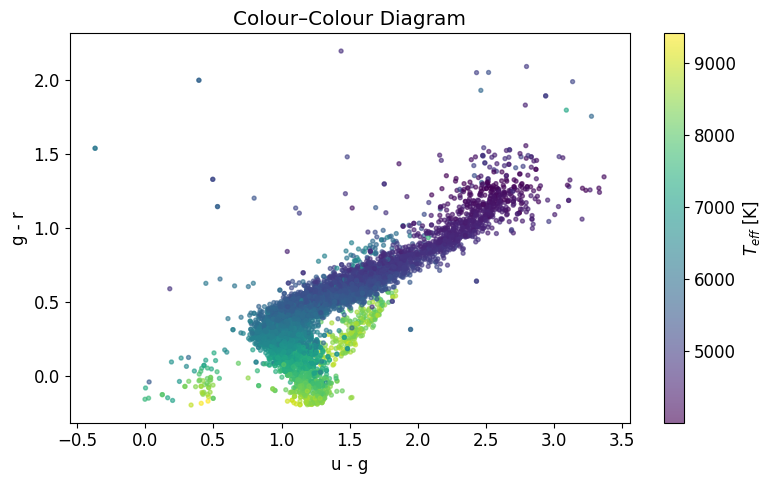

In [9]:
plt.scatter(df["u_g"], df["g_r"], c=df["Teff"], s=8, alpha=0.6, cmap="viridis")
plt.ylabel("g - r")
plt.xlabel("u - g")
plt.title("Colour–Colour Diagram")
plt.colorbar(label=r"$T_{eff}$ [K]")
plt.tight_layout()
plt.show()


## Train / test split

We split the dataset into:

- **Training set:** used to fit model parameters  
- **Test set:** held back until the end for unbiased evaluation  

###### Why this is necessary

The goal is to prevent overfitting. A model can simply memorise the 3,000 synthetic stars without learning any underlying physical relationship.

Such memorisation would give excellent training performance but poor generalisation to new, unseen stars.

By evaluating on a held-out test set, we verify whether the model has learned a physically meaningful mapping between colours and temperature.

###### Target variable (y)

We use $\log_{10}(T_{\rm eff})$ as the target:

- This ensures that errors are interpreted in relative (percentage) terms  
- A 5% error at 4000 K is treated similarly to a 5% error at 8000 K  

###### Feature set (X)

We provide the model with four colour indices:

- $u-g$, $g-r$, $r-i$, $i-z$

While a single colour gives a rough estimate of temperature, multiple colours allow the model to disentangle effects such as dust reddening and metallicity, improving robustness and reducing degeneracies.

In [10]:
# Four colours help break degeneracies caused by dust and metallicity.

features = ["u_g", "g_r", "r_i", "i_z"]
X = df[features]
y = df["log_Teff"]


In [11]:
# test_size=0.25: You are hiding 25% of your stars in the test set
# random_state=SEED: This makes the experiment reproducible and we get the exact same stars in their training set.

X_train, X_test, y_train, y_test, sig_train, sig_test = train_test_split(
    X,
    y,
    df["sigma_phot"],
    test_size=0.25,
    random_state=SEED
)

print("Training stars:", len(X_train))
print("Test stars:", len(X_test))


Training stars: 6750
Test stars: 2250


## Inverse-variance weighting

In standard regression models, each data point contributes equally to the loss function.

However, in this dataset, some measurements are more reliable than others: bright, unreddened stars have small uncertainties, while faint or dusty stars are significantly noisier.

We incorporate this by using inverse-variance weighting based on photometric uncertainty:

$
w_{\text{train}} = \frac{1}{\sigma_{\text{train}}^2}
$

This reflects a standard principle in scientific inference: more precise measurements should contribute more strongly to parameter estimation.

###### Intuition

- If $\sigma_{\text{train}} = 0.01$, then $w = 10{,}000$
- If $\sigma_{\text{train}} = 0.2$, then $w = 25$

Thus, high-precision measurements dominate the optimisation, while noisy points have reduced influence.

###### Effect on learning

The model is therefore encouraged to prioritise fitting the most reliable data more accurately, rather than being driven by high-uncertainty observations.

This prevents low signal-to-noise measurements from disproportionately degrading model performance and aligns the training objective with measurement reliability.

In [12]:
# Avoid division by zero
sig_train_safe = np.clip(sig_train, 1e-4, None)
w_train = 1.0 / sig_train_safe**2
# Normalise weights (important for some models)
w_train = w_train / np.mean(w_train)

## Utility functions

We define standard regression metrics to compare model performance.

###### RMSE (Root Mean Squared Error)

RMSE penalises large errors more strongly because residuals are squared before averaging.

- Highly sensitive to outliers  
- If a model performs well on most stars but fails on a few extreme cases (e.g. highly reddened or noisy stars), RMSE will increase significantly  
- For Gaussian errors, RMSE is directly related to the standard deviation of the residuals  

###### MAE (Mean Absolute Error)

MAE measures the typical magnitude of prediction errors.

- More robust to outliers than RMSE  
- Interpreted as the expected absolute error for a random star in the sample  
- A large gap between RMSE and MAE can indicate the presence of a small number of severe prediction failures  

###### $R^2$ (Coefficient of determination)

$R^2$ measures the fraction of variance in the target explained by the model:

- $R^2 = 1$: perfect prediction  
- $R^2 = 0$: model performs no better than predicting the mean temperature  

Given the wide temperature range in the catalogue (3500 K to 9000 K), a high \(R^2\) indicates that the model has successfully learned the underlying temperature structure despite noise from dust, metallicity, and measurement uncertainty.

In [13]:
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": name,
        "RMSE [dex]": rmse,
        "MAE [dex]": mae,
        "R2": r2
    }


## Naive baseline

In machine learning, it is essential to compare any model against a simple baseline before trusting more complex approaches.

As a baseline, we ignore all photometric features ($u$, $g$, $r$, $i$, $z$) and any physical modelling. Instead, we compute the mean temperature of the training set and predict this constant value for all test samples.

This is equivalent to assuming that every star has the same effective temperature, regardless of its observed properties.

In astronomy, such baselines are useful for assessing whether new data or models provide real predictive power. If a model using multiple photometric bands performs no better than this trivial predictor, it suggests one of the following:

- The photometric data are too noisy to contain useful signal  
- The target quantity is weakly or non-trivially correlated with the available features  
- The modelling approach is incorrect or underpowered  

In this sense, the mean baseline acts as a control experiment. It provides a reference point against which all subsequent models (e.g. linear regression or ensemble methods) must demonstrate improvement to be considered meaningful.

In [14]:
# y_train.mean(): Finds the average log 10 (T eff) of the training data.
y_mean = y_train.mean()

# np.repeat(..., len(y_test)): Creates a list for the test set where every entry is that average value.
baseline_pred = np.repeat(y_mean, len(y_test))

print(pd.Series(
    evaluate_model("Mean baseline", y_test, baseline_pred)
))

Model         Mean baseline
RMSE [dex]         0.068473
MAE [dex]          0.053177
R2                -0.001205
dtype: object


Notice that while $R^2 \approx 0$, the baseline still produces a relatively large RMSE.

This RMSE reflects the intrinsic spread of temperatures in the dataset rather than any predictive ability of the model.

In fact, for this constant predictor, the RMSE is directly related to the standard deviation of the target distribution (i.e. the variability of stellar temperatures in the catalogue).

## Classical single-colour calibration

In traditional empirical astronomy, stellar effective temperature is often estimated using a single colour index through a linear calibration.

Here, we use a single feature, $g - r$, and fit a straight-line model using ordinary least squares.

Historically, this approach was common because many surveys only provided two photometric bands (e.g. $B$ and $V$), where $(B - V)$ served as a basic stellar thermometer.

We model the relationship as:

$
\log_{10}(T_{\rm eff}) = m \cdot (g - r) + c
$

This represents a simple 1D empirical calibration between colour and temperature.

###### Weighted least squares

Standard linear regression treats all stars equally. Here, we instead use **weighted least squares**, incorporating observational uncertainties.

We define:

$
w_{\text{train}} = \frac{1}{\sigma_{\text{train}}^2}
$

This encodes the idea that more precise measurements should contribute more strongly to the fit.

By passing `w_train` to the model, we are effectively telling it:

- High-uncertainty (noisy) stars should have less influence on the fit  
- High-precision stars should dominate the parameter estimation  

This is physically motivated, as it prevents faint or highly reddened stars from biasing the calibration and ensures the model prioritises reliable photometric measurements.

In [15]:
lin1_model = LinearRegression()
lin1_model.fit(X_train[["g_r"]], y_train, sample_weight=w_train)


lin1_pred = lin1_model.predict(X_test[["g_r"]]) # This is a test of Generalization. 


print(pd.Series(
    evaluate_model("Linear (g-r only)", y_test, lin1_pred)
))

Model         Linear (g-r only)
RMSE [dex]             0.033452
MAE [dex]              0.019322
R2                     0.761044
dtype: object


In [16]:
# 1. Select the first test sample as a DataFrame (keeps feature names)
sample_df = X_test[["g_r"]].iloc[[0]] 
print("Training Sample:")
print(sample_df)
# 2. Predict directly
# No warning! No reshaping needed!

sample_model_pred = lin1_model.predict(sample_df)[0]
print(f"\nIntercept:\t{lin1_model.intercept_:.4f}")
print(f"Coefficients:\t{lin1_model.coef_}" )

# 3. Manual calculation (for the student's understanding)
# We still use .values here because math operations are cleaner with arrays
sample_manual_pred = (sample_df.values @ lin1_model.coef_) + lin1_model.intercept_
print(f"\nModel .predict():                     {sample_model_pred:.4f}")
print(f"Manual Calculation:                     {sample_manual_pred[0]:.4f}")
print(f"Actual Target (y_test):                 {y_test.iloc[0]:.4f}")

Training Sample:
          g_r
7940  0.43525

Intercept:	3.8775
Coefficients:	[-0.23863895]

Model .predict():                     3.7736
Manual Calculation:                     3.7736
Actual Target (y_test):                 3.7579


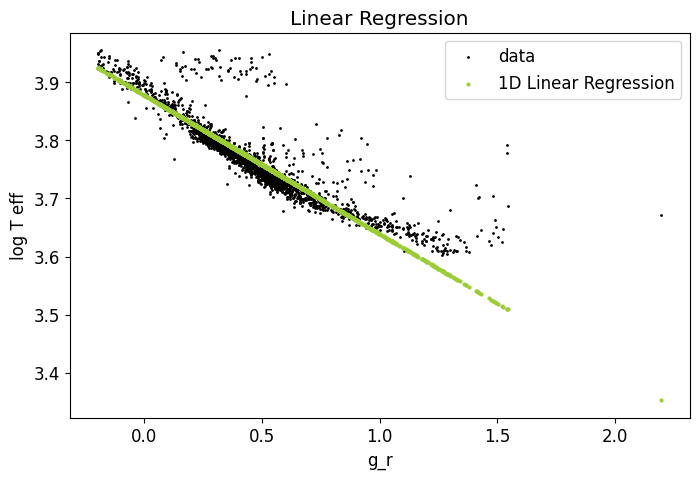

In [17]:
plt.figure()
plt.scatter(X_test[["g_r"]], y_test,    s=1, edgecolor="black", c="darkorange", label="data")
plt.scatter(X_test[["g_r"]], lin1_pred, s=1,color="yellowgreen", label="1D Linear Regression", linewidth=2)
plt.xlabel("g_r")
plt.ylabel("log T eff")
plt.title("Linear Regression")
plt.legend()
plt.show()

When we predict on the test set, the model takes 750 previously unseen stars and estimates their $\log_{10}(T_{\rm eff})$ using only their $g-r$ values.

If the model performs well, this indicates that the $g-r$–temperature relation behaves as an approximately universal physical mapping within this simulated dataset.

Although this single-colour model significantly outperforms the mean baseline, it still exhibits non-negligible errors for two main reasons:

### Underfitting (model misspecification)

The true colour–temperature relation is nonlinear, as discussed earlier.

A linear model cannot capture this curvature, leading to systematic errors at the hot and cool extremes of the temperature range.

### Degeneracy (hidden variables)

The model only uses $g-r$ and therefore cannot disentangle different physical effects that produce similar colours.

In particular, it cannot distinguish whether a star appears red because it is:
- intrinsically cool  
- affected by interstellar dust  
- influenced by metallicity effects  

These unobserved variables introduce irreducible ambiguity in the mapping from colour to temperature.

## Multicolour linear regression

We extend the model from a single colour (“1D thermometer”) to a four-dimensional feature space using all available colour indices.

The model now uses $u-g$, $g-r$, $r-i$, and $i-z$ simultaneously as predictors of stellar temperature.

We assume a linear form:

$
\log_{10}(T_{\rm eff}) =
\beta_0 + \beta_1 (u-g) + \beta_2 (g-r) + \beta_3 (r-i) + \beta_4 (i-z)
$

###### Breaking degeneracies

Compared to the single-colour model, this approach provides additional constraints on the inverse problem.

A single colour (e.g. $g-r$) cannot distinguish between:
- intrinsically cool stars  
- hot stars affected by dust reddening  

By incorporating multiple bands, the model can partially disentangle these effects:
- dust reddening follows a wavelength-dependent pattern consistent with the extinction law  
- intrinsic stellar colour variations follow a different multiband structure  

###### Statistical advantage

Even in the absence of astrophysical degeneracies, additional features improve performance.

Each colour measurement carries independent observational noise, so combining multiple bands helps reduce the impact of random errors and improves robustness.

###### Feature roles (intuition)

- $u-g$: highly sensitive to temperature and metallicity, but relatively noisy  
- $g-r$, $r-i$: provide a stable baseline for the main temperature trend  
- $i-z$: less affected by dust, helping constrain reddening effects  

###### Interpretation of results

When comparing to the single-colour model, RMSE should decrease and $R^2$ should increase, indicating that additional photometric information improves predictive power.

However, the model remains linear in the input space: it fits a hyperplane in four dimensions, whereas the true relation is nonlinear. 

As a result, it still cannot fully capture curvature in the colour–temperature relation.

In [18]:
lin4_model = LinearRegression()
lin4_model.fit(X_train, y_train, sample_weight=w_train)

lin4_pred = lin4_model.predict(X_test)

print(pd.Series(
    evaluate_model("Linear (4 colours)", y_test, lin4_pred)
))


Model         Linear (4 colours)
RMSE [dex]              0.033241
MAE [dex]               0.017288
R2                      0.764049
dtype: object


In [19]:
# 1. Select the first test sample as a DataFrame (keeps feature names)
sample_df = X_test.iloc[[0]] 
print("Training Sample:")
print(sample_df)
# 2. Predict directly
# No warning! No reshaping needed!

sample_model_pred = lin4_model.predict(sample_df)[0]
print(f"\nIntercept:\t{lin4_model.intercept_:.4f}")
print(f"Coefficients:\t{lin4_model.coef_}" )

# 3. Manual calculation (for the student's understanding)
# We still use .values here because math operations are cleaner with arrays
sample_manual_pred = (sample_df.values @ lin4_model.coef_) + lin4_model.intercept_
print(f"\nModel .predict():                   {sample_model_pred:.4f}")
print(f"Manual Calculation:                   {sample_manual_pred[0]:.4f}")
print(f"Actual Target (y_test):               {y_test.iloc[0]:.4f}")

Training Sample:
          u_g      g_r      r_i      i_z
7940  1.20961  0.43525  0.16658  0.02797

Intercept:	3.8321
Coefficients:	[ 0.06020014 -0.33786167  0.0181095   0.10428745]

Model .predict():                   3.7638
Manual Calculation:                   3.7638
Actual Target (y_test):               3.7579


## Nonlinear regression: polynomial features

Linear regression is limited to learning hyperplanes in feature space. Polynomial feature expansion allows it to represent nonlinear relationships by introducing curvature and feature interactions.

We now introduce feature engineering via a pipeline.

This is the first model in the notebook capable of capturing the curvature of the colour–temperature relation more effectively.

##### The pipeline

A **pipeline** chains multiple preprocessing and modelling steps into a single object.

It ensures that:
- the same transformations are applied consistently during training and testing  
- steps occur in the correct order  
- data leakage is avoided  
- the code remains modular and reproducible  

###### Polynomial features (degree = 2)

`PolynomialFeatures(degree=2)` augments the original feature set by generating nonlinear combinations.

For two generic features \(a\) and \(b\), it produces:
- Original terms: \(a\), \(b\)  
- Quadratic terms: \(a^2\), \(b^2\)  
- Interaction terms: \(ab\)  

Applied to multiple colour indices, this allows a linear model to fit curved surfaces in higher-dimensional space.

###### Standardisation

Polynomial expansion can produce features with widely different numerical scales.

For example:
- \(2.0^2 = 4.0\)  
- \(0.1^2 = 0.01\)  

`StandardScaler()` rescales each feature to have zero mean and unit variance, improving numerical stability and ensuring no feature dominates purely due to scale.

###### Expected behaviour

This model typically yields:
- higher \(R^2\)  
- lower RMSE  

compared to linear models.

It combines:
- **multi-band information** (reducing reddening and metallicity degeneracies)  
- **nonlinear feature interactions** (capturing curvature in the colour–temperature relation)  

Among classical regression approaches, this is the most expressive model used so far in the notebook.

In [20]:
poly2_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    # We tell the scaler to ignore the weights
    ("scale", StandardScaler().set_fit_request(sample_weight=False)),
    # We tell the regression to request/use the weights
    ("reg", LinearRegression().set_fit_request(sample_weight=True))
])

poly2_model.fit(X_train, y_train, sample_weight=w_train)

poly2_pred = poly2_model.predict(X_test)

print(pd.Series(
    evaluate_model("Polynomial degree 2", y_test, poly2_pred)
))


Model         Polynomial degree 2
RMSE [dex]               0.036959
MAE [dex]                0.017476
R2                       0.708311
dtype: object


## Overfitting and regularization

High-degree polynomial models have enough flexibility to fit not only the underlying signal but also the observational noise.

To control this, we use regularization techniques:

- **Ridge regression:** applies smooth shrinkage to all coefficients  
- **Lasso regression:** can drive some coefficients exactly to zero, performing implicit feature selection  

We now increase model complexity by allowing polynomial features up to degree 8.

This increases the model’s capacity to represent fine structure in the data, including subtle astrophysical effects such as spectral features.

However, higher model flexibility introduces a major risk: **overfitting**.

The model may begin to fit noise-specific fluctuations (“wiggles”) in the training set rather than learning the true underlying physical relationship.

In [21]:
max_order = 8
highorder_poly_models = [None] * len(range(1,max_order+1))
highorder_poly_preds  = [None] * len(range(1,max_order+1))

for i,n in enumerate(range(1,max_order+1)):
    highorder_poly_models[i] = Pipeline([
        ("poly", PolynomialFeatures(degree=n, include_bias=False)),
        ("scale", StandardScaler().set_fit_request(sample_weight=False)),
        ("reg", LinearRegression().set_fit_request(sample_weight=True))
    ])

    highorder_poly_models[i].fit(X_train, y_train, sample_weight=w_train)
    highorder_poly_preds[i] = highorder_poly_models[i].predict(X_test)

    print(pd.Series(
        evaluate_model(f"Polynomial degree {n}", y_test, highorder_poly_preds[i])
    ), "\n")


Model         Polynomial degree 1
RMSE [dex]               0.033241
MAE [dex]                0.017288
R2                       0.764049
dtype: object 

Model         Polynomial degree 2
RMSE [dex]               0.036959
MAE [dex]                0.017476
R2                       0.708311
dtype: object 

Model         Polynomial degree 3
RMSE [dex]               0.133192
MAE [dex]                0.019141
R2                      -2.788267
dtype: object 

Model         Polynomial degree 4
RMSE [dex]               0.174508
MAE [dex]                0.023157
R2                      -5.503013
dtype: object 

Model         Polynomial degree 5
RMSE [dex]               2.367385
MAE [dex]                0.093694
R2                   -1195.793917
dtype: object 

Model         Polynomial degree 6
RMSE [dex]               5.104065
MAE [dex]                0.171525
R2                   -5562.060841
dtype: object 

Model         Polynomial degree 7
RMSE [dex]             279.631317
MAE [dex]           

In [22]:
max_order = 8
highorder_poly_models = [None] * len(range(1,max_order+1))
scores_poly_train = [None] * len(range(1,max_order+1))
scores_poly_test  = [None] * len(range(1,max_order+1))

for i,n in enumerate(range(1,max_order+1)):
    highorder_poly_models[i] = Pipeline([
        ("poly", PolynomialFeatures(degree=n, include_bias=False)),
        ("scale", StandardScaler().set_fit_request(sample_weight=False)),
        ("reg", LinearRegression().set_fit_request(sample_weight=True))
    ])

    highorder_poly_models[i].fit(X_train, y_train, sample_weight=w_train)
    scores_poly_train[i] = highorder_poly_models[i].score(X_train, y_train)
    scores_poly_test[i]  = highorder_poly_models[i].score(X_test, y_test)

    print(f"Score for Polynomial degree {n} on Train set:\t{scores_poly_train[i]}")
    print(f"Score for Polynomial degree {n} on Test  set:\t{scores_poly_test[i] }\n")



Score for Polynomial degree 1 on Train set:	0.7767708729195656
Score for Polynomial degree 1 on Test  set:	0.7640494895926733

Score for Polynomial degree 2 on Train set:	0.7572838996683314
Score for Polynomial degree 2 on Test  set:	0.7083111186343127

Score for Polynomial degree 3 on Train set:	0.7943342975999516
Score for Polynomial degree 3 on Test  set:	-2.788267270398678

Score for Polynomial degree 4 on Train set:	0.8031072514267621
Score for Polynomial degree 4 on Test  set:	-5.503012975019229

Score for Polynomial degree 5 on Train set:	0.8518207955565351
Score for Polynomial degree 5 on Test  set:	-1195.793916677661

Score for Polynomial degree 6 on Train set:	0.8830046943825789
Score for Polynomial degree 6 on Test  set:	-5562.060840681685

Score for Polynomial degree 7 on Train set:	0.9120647974650256
Score for Polynomial degree 7 on Test  set:	-16697562.70060423

Score for Polynomial degree 8 on Train set:	0.9237880637189453
Score for Polynomial degree 8 on Test  set:	-753

## Bias–variance tradeoff

The results illustrate the classic bias–variance tradeoff:

- **Low degree (high bias):** Simple models (e.g. linear) are too rigid and cannot capture the underlying nonlinear structure of the data.  
- **High degree (high variance):** Very flexible models can fit the training data extremely well, but they also begin to fit noise, leading to poor generalisation.

For example, at polynomial degree 4, the feature expansion includes higher-order interaction terms such as \(a^2 b^2\), \(a^3 b\), and \(a^4\).

With four input colours, this expansion produces 70 features in total. A standard linear regression would assign a coefficient to each of these terms, increasing the risk of overfitting and producing unstable, “noisy” predictions.

### Regularization

To mitigate overfitting, we introduce regularization methods that constrain model complexity while retaining expressive power.

###### Ridge regression ($L2$ regularization)

`Ridge(alpha=10)` adds a penalty proportional to the squared magnitude of the coefficients.

- Encourages small coefficients without eliminating them entirely  
- Smoothly shrinks all feature weights  
- Prevents any single high-order term (e.g. \(u_g^4\)) from dominating unless strongly supported by the data  

###### Lasso regression ($L1$ regularization)

`Lasso(alpha=1e-5)` penalises the absolute value of coefficients.

- Encourages sparsity in the model  
- Can set some coefficients exactly to zero  
- Performs automatic feature selection among the 70 polynomial terms  

In this context, Lasso tends to retain only the most physically meaningful interactions while discarding redundant or noise-driven features.

### Importance of standardisation

`StandardScaler` is essential when using Ridge or Lasso because regularisation depends on coefficient magnitude.

Without scaling, features with larger numerical ranges would be penalised more heavily than those with smaller ranges, leading to biased optimisation. Standardisation ensures that all features contribute on a comparable scale, making regularisation meaningful and fair.


In [23]:
poly4_model = Pipeline([
    ("poly", PolynomialFeatures(degree=4, include_bias=False)),
    ("scale", StandardScaler().set_fit_request(sample_weight=False)),
    ("reg", LinearRegression().set_fit_request(sample_weight=True))
])


ridge4_model = Pipeline([
    ("poly", PolynomialFeatures(degree=4, include_bias=False)),
    ("scale", StandardScaler().set_fit_request(sample_weight=False)),
#    ("reg", Ridge(alpha=10).set_fit_request(sample_weight=True))
    ("reg", Ridge(alpha=1e2).set_fit_request(sample_weight=True))
])

lasso4_model = Pipeline([
    ("poly", PolynomialFeatures(degree=4, include_bias=False)),
    ("scale", StandardScaler().set_fit_request(sample_weight=False)),
    ("reg", Lasso(alpha=1e-4, max_iter=10000).set_fit_request(sample_weight=True))
])

poly4_model.fit(X_train, y_train, sample_weight=w_train)
ridge4_model.fit(X_train, y_train, sample_weight=w_train)
lasso4_model.fit(X_train, y_train, sample_weight=w_train)

poly4_pred  = poly4_model.predict(X_test)
ridge4_pred = ridge4_model.predict(X_test)
lasso4_pred = lasso4_model.predict(X_test)

for name,pred in zip(["Linear", "Ridge", "Lasso"], [poly4_pred, ridge4_pred, lasso4_pred]):
    print(pd.Series(
        evaluate_model(f"{name} " + "Regression for Polynomial Degree 4", y_test, pred)
    ), "\n")



Model         Linear Regression for Polynomial Degree 4
RMSE [dex]                                     0.174508
MAE [dex]                                      0.023157
R2                                            -5.503013
dtype: object 

Model         Ridge Regression for Polynomial Degree 4
RMSE [dex]                                    0.026483
MAE [dex]                                      0.01548
R2                                            0.850232
dtype: object 

Model         Lasso Regression for Polynomial Degree 4
RMSE [dex]                                    0.026854
MAE [dex]                                      0.01544
R2                                            0.846011
dtype: object 



In [24]:
poly4_score_train = poly4_model.score( X_train, y_train)
ridge4_score_train = ridge4_model.score(X_train, y_train)
lasso4_score_train = lasso4_model.score(X_train, y_train)

poly4_score_test = poly4_model.score( X_test, y_test)
ridge4_score_test = ridge4_model.score(X_test, y_test)
lasso4_score_test = lasso4_model.score(X_test, y_test)

for name, score in zip(["Linear", "Ridge", "Lasso"], [poly4_score_train, ridge4_score_train, lasso4_score_train]):
    print(f"Score on Train set for {name} Regression:\t{score}")

print()
for name, score in zip(["Linear", "Ridge", "Lasso"], [poly4_score_test, ridge4_score_test, lasso4_score_test]):
    print(f"Score on  Test set for {name} Regression:\t{score}")


Score on Train set for Linear Regression:	0.8031072514267621
Score on Train set for Ridge Regression:	0.8377668189377396
Score on Train set for Lasso Regression:	0.8448170939616981

Score on  Test set for Linear Regression:	-5.503012975019229
Score on  Test set for Ridge Regression:	0.8502315446816264
Score on  Test set for Lasso Regression:	0.8460110852334829


In [25]:
results = pd.DataFrame([
    evaluate_model("Mean baseline", y_test, baseline_pred),
    evaluate_model("Linear (g-r only)", y_test, lin1_pred),
    evaluate_model("Linear (4 colours)", y_test, lin4_pred),
    evaluate_model("Poly deg2", y_test, poly2_pred),
    evaluate_model("Poly deg4", y_test, poly4_pred),
    evaluate_model("Ridge deg4", y_test, ridge4_pred),
    evaluate_model("Lasso deg4", y_test, lasso4_pred),
])

results = results.sort_values("RMSE [dex]")
results


,Model,RMSE [dex],MAE [dex],R2
5,Ridge deg4,0.026483,0.015480,0.850232
6,Lasso deg4,0.026854,0.015440,0.846011
2,Linear (4 colours),0.033241,0.017288,0.764049
1,Linear (g-r only),0.033452,0.019322,0.761044
3,Poly deg2,0.036959,0.017476,0.708311
0,Mean baseline,0.068473,0.053177,-0.001205
4,Poly deg4,0.174508,0.023157,-5.503013
